In [6]:
# Install if not already installed
# %pip install pandas
# %pip install xlrd

import pandas as pd
import json

In [7]:
# Caricare il file Excel
file_path = "./dev/msb201066-sup-0002.xls"
file_name = file_path.split("/")[-1]
print(f"Loading {file_name}...")

excel_data = pd.read_excel(file_path, sheet_name=None, header=None)

Loading msb201066-sup-0002.xls...


In [12]:
# Write sheets as csvs
# 'ReadMe', 'Day1_Rep1', 'Day1_Rep2', 'Day2_Rep1', 'Day2_Rep2', 'Day3_Rep1', 'Day3_Rep2', 'Day4_Rep1', 'Day4_Rep2', 'mCherry_Counts', 'Venus_Counts'
for key in excel_data.keys():
    fn = f"raw.msb201066-sup-0002.{key}.csv"
    print(fn)
    excel_data[key].to_csv(fn)


raw.msb201066-sup-0002.ReadMe.csv
raw.msb201066-sup-0002.Day1_Rep1.csv
raw.msb201066-sup-0002.Day1_Rep2.csv
raw.msb201066-sup-0002.Day2_Rep1.csv
raw.msb201066-sup-0002.Day2_Rep2.csv
raw.msb201066-sup-0002.Day3_Rep1.csv
raw.msb201066-sup-0002.Day3_Rep2.csv
raw.msb201066-sup-0002.Day4_Rep1.csv
raw.msb201066-sup-0002.Day4_Rep2.csv
raw.msb201066-sup-0002.mCherry_Counts.csv
raw.msb201066-sup-0002.Venus_Counts.csv


In [9]:
%pwd

'/Users/Pereiro/University/CODE/PaperSON/data/wintermuteEmergentCooperationMicrobial2010'

0  NaN values in difference matrix


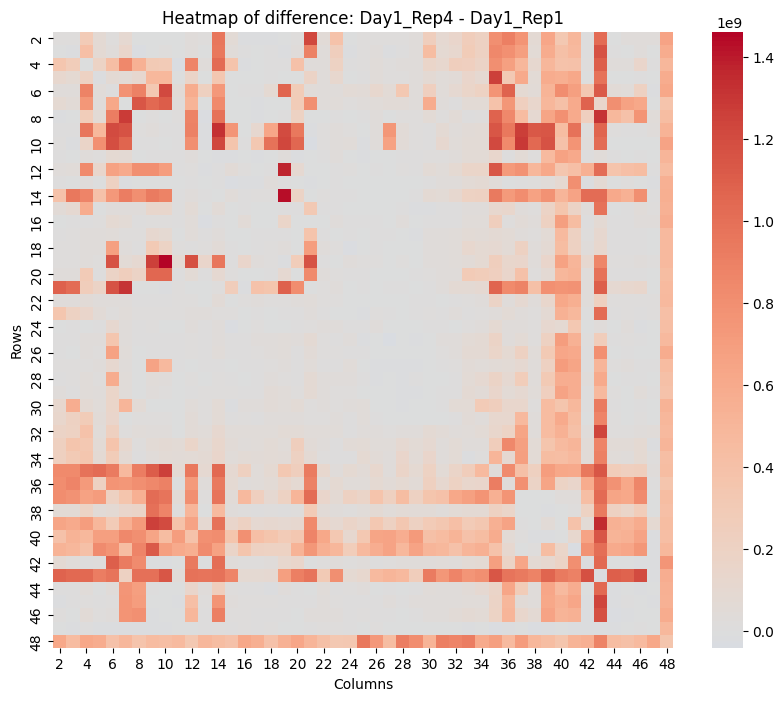

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Extract the relevant DataFrame slices
df1 = excel_data["Day1_Rep1"].iloc[2:, 2:]
df4 = excel_data["Day4_Rep1"].iloc[2:, 2:]

# Convert both to numeric (important for Excel data with mixed types)
df1_numeric = df1.apply(pd.to_numeric, errors='coerce')
df4_numeric = df4.apply(pd.to_numeric, errors='coerce')

# Align indices and columns to be safe (optional, in case structure differs)
df4_numeric = df4_numeric.loc[df1_numeric.index, df1_numeric.columns]

# Compute difference
diff = df4_numeric - df1_numeric

# Optionally inspect for NaNs
print(diff.isna().sum().sum(), " NaN values in difference matrix")

# Replace NaNs with 0 or another sentinel if desired for plotting
diff = diff.fillna(0)

# Plot using seaborn
plt.figure(figsize=(10,8))
sns.heatmap(diff, cmap='coolwarm', center=0, annot=False)
plt.title("Heatmap of difference: Day1_Rep4 - Day1_Rep1")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


In [ ]:
def sheet1_csv():
    # "Sheet 1"
    excel_data0 = excel_data["Sheet 1"]
    dat1 = excel_data0.iloc[6:].copy()  # Prende tutto dopo la riga 5
    dat1.columns = excel_data0.iloc[5]  # Imposta le nuove intestazioni

    # Reset degli indici (opzionale)
    dat1.reset_index(drop=True, inplace=True)
    csv_file_path = f"./raw.{file_name}.sheet1.dat.csv"
    dat1.to_csv(csv_file_path, index=False)
sheet1_csv()

In [ ]:
# DEV
excel_data["Info"].T.to_csv("./dev/_temp.csv", index=False, na_rep="null")